# Top1-Top2 Fark Analizi ile Cevap Doğruluğu Tahmini
**Hesaplamalı Anlambilim Dersi – Final Projesi**

**Model:** Cosmos-T1 (`ytu-ce-cosmos/Turkish-Gemma-9b-T1`)  
**Dataset:** gsm8k_tr (`ytu-ce-cosmos/gsm8k_tr`)  
**Yöntem:** Modelin her token için top1−top2 olasılık farkını alıp, bundan istatistiksel özellikler çıkararak cevabın doğru/yanlış olduğunu ML ile tahmin etmek  
**GPU:** A100  

---
## Akış
```
gsm8k_tr  →  Cosmos-T1 (vLLM, logprobs=2)  →  top1-top2 fark dizisi + doğru/yanlış etiketi
         →  Dengeli dataset (1000 train + 100 test)  →  Özellik çıkarma  →  ML eğitim+test
         →  Confusion Matrix + Metrikler + Feature Importance
```

## 0. Oturum Kurulumu (Her Restart Sonrası Çalıştır)

In [1]:
from google.colab import drive
import os, gc

drive.mount('/content/drive')

ROOT = '/content/drive/MyDrive/top1top2_proje'
os.makedirs(ROOT, exist_ok=True)

PATHS = {
    'root'        : ROOT,
    'data'        : f'{ROOT}/data',
    'generations' : f'{ROOT}/generations',
    'results'     : f'{ROOT}/results',
    'figures'     : f'{ROOT}/figures',
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

import json, re, numpy as np
print('Drive bağlandı. ROOT:', ROOT)

Mounted at /content/drive
Drive bağlandı. ROOT: /content/drive/MyDrive/top1top2_proje


## 1. Kurulum

In [2]:
# Transformers modu: vLLM kullanılmıyor.
!pip install -q -U transformers accelerate datasets scikit-learn scipy matplotlib seaborn
print("Kurulum tamam. Paket güncellendiyse Runtime > Restart runtime yapıp baştan çalıştır.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 51.2 MB/s eta 0:00:00
Kurulum tamam. Paket güncellendiyse Runtime > Restart runtime yapıp baştan çalıştır.


In [ ]:
import torch
print('GPU:', torch.cuda.get_device_name(0))
print('VRAM:', f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42 GB


## 2. Yardımcı Fonksiyonlar

In [3]:
def _normalize_num(tok):
    tok = tok.strip()
    has_dot, has_com = '.' in tok, ',' in tok
    if has_dot and has_com:
        if tok.rfind(',') > tok.rfind('.'):
            tok = tok.replace('.', '').replace(',', '.')
        else:
            tok = tok.replace(',', '')
    elif has_dot:
        p = tok.split('.')
        if len(p) > 2 or (len(p) == 2 and len(p[1]) == 3 and len(p[0]) <= 3):
            tok = tok.replace('.', '')
    elif has_com:
        p = tok.split(',')
        if len(p) == 2 and len(p[1]) == 3:
            tok = tok.replace(',', '')
        else:
            tok = tok.replace(',', '.')
    try:
        v = float(tok)
        return int(v) if v == int(v) else v
    except:
        return None

def extract_number(text):
    """#### formatından sayı çıkar; yoksa son sayıyı dene."""
    m = re.findall(r'####\s*([\-+]?[\d.,]+)', text)
    if m:
        v = _normalize_num(m[-1])
        if v is not None:
            return v
    nums = re.findall(r'[\-+]?\d[\d.,]*', text)
    for n in reversed(nums):
        v = _normalize_num(n)
        if v is not None:
            return v
    return None

def is_correct(pred, gold, tol=1e-3):
    if pred is None or gold is None:
        return False
    return abs(float(pred) - float(gold)) <= tol

print('Yardımcı fonksiyonlar hazır.')

Yardımcı fonksiyonlar hazır.


## 3. Dataset Hazırlama

In [ ]:
from datasets import load_dataset
import random, json

random.seed(42)
np.random.seed(42)

ds = load_dataset('ytu-ce-cosmos/gsm8k_tr')
print(ds)

# train split kullan
ds_train = ds['train']
print(f'Train split: {len(ds_train)} örnek')
print('Sütunlar:', ds_train.column_names)
print('\nİlk örnek:')
print('SORU:', ds_train[0]['question'])
print('CEVAP:', ds_train[0]['answer'][:200])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 8792
    })
})
Train split: 8792 örnek
Sütunlar: ['question', 'answer']

İlk örnek:
SORU: Borris tekel bayisi her 6 ayda bir 90 kilogram üzüm kullanıyor. Üretimini yüzde yirmi oranında artırmayı düşünüyor. Üretimini artırdıktan sonra bir yıl içinde kaç üzüme ihtiyacı olur?
CEVAP: Borris şu anda her 6 ayda 90 kilogram üzüm kullanıyorsa, bir yılda 180 kilogram üzüm kullanıyor demektir. Üretimini yüzde 20 oranında artırırsa:

180 kilogram x 1.20 = 216 kilogram

Buna göre, üretimi


In [ ]:
# Gold cevabı olan tüm örnekleri al ve karıştır
temiz = []
for i, ex in enumerate(ds_train):
    g = extract_number(ex['answer'])
    if g is None:
        continue
    temiz.append({
        'id'      : i,
        'question': ex['question'].strip(),
        'answer'  : ex['answer'].strip(),
        'gold'    : g,
    })

print(f'Temiz örnek: {len(temiz)}  (atılan: {len(ds_train) - len(temiz)})')

random.shuffle(temiz)

# Tüm havuzu kaydet — sonra dengeli subset seçeceğiz
with open(f"{PATHS['data']}/all_questions.json", 'w', encoding='utf-8') as f:
    json.dump(temiz, f, ensure_ascii=False, indent=2)
print('Kaydedildi:', f"{PATHS['data']}/all_questions.json")

Temiz örnek: 8768  (atılan: 24)
Kaydedildi: /content/drive/MyDrive/top1top2_proje/data/all_questions.json


## 4. Cosmos-T1 ile Üretim (vLLM + logprobs=2)

> **Anahtar:** `SamplingParams(logprobs=2)` ile her token adımında top-2 token ve log-olasılıklarını alıyoruz.  
> Top1−Top2 **olasılık farkı** = `exp(logprob_top1) − exp(logprob_top2)`  
> Bu fark büyükse model emin, küçükse kararsız demektir.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = 'ytu-ce-cosmos/Turkish-Gemma-9b-T1'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map='auto',
    trust_remote_code=True,
)
model.eval()

print('Model yüklendi:', MODEL_NAME)
print('VRAM kullanımı:', f"{torch.cuda.memory_allocated()/1e9:.1f} GB")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

Model yüklendi: ytu-ce-cosmos/Turkish-Gemma-9b-T1
VRAM kullanımı: 18.5 GB


In [ ]:
SYSTEM = (
    'Sen matematik problemleri çözen bir asistansın. '
    'Problemi adım adım Türkçe çöz. '
    'Cevabın en sonunda mutlaka şu formatta nihai sayıyı yaz: #### <sayı>'
)

def build_prompt(question):
    messages = [
        {'role': 'system', 'content': SYSTEM},
        {'role': 'user',   'content': question},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

# Test
print(build_prompt('5 + 3 kaçtır?')[:200])

<bos><start_of_turn>system
Sen matematik problemleri çözen bir asistansın. Problemi adım adım Türkçe çöz. Cevabın en sonunda mutlaka şu formatta nihai sayıyı yaz: #### <sayı><end_of_turn>
<start_of_tu


In [ ]:
print('Prompt builder hazır (transformers modu).')

Prompt builder hazır (transformers modu).


In [ ]:
import math, time

MAX_NEW_TOKENS = 512
BATCH_SIZE     = 8

def top_diffs_from_scores(scores):
    diffs = []
    for step_logits in scores:
        probs = torch.softmax(step_logits[0].float(), dim=-1)  # .float(): bfloat16 → float32
        top2  = torch.topk(probs, k=2)
        diffs.append((top2.values[0] - top2.values[1]).item())
    return diffs


def generate_batch(questions_batch):
    prompts = [build_prompt(q['question']) for q in questions_batch]
    enc = tokenizer(
        prompts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=1024,
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tokenizer.pad_token_id,
        )

    prompt_len = enc['input_ids'].shape[1]
    results = []
    for i in range(len(questions_batch)):
        gen_ids  = out.sequences[i, prompt_len:]
        gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        n_gen    = (gen_ids != tokenizer.pad_token_id).sum().item()
        step_scores = [out.scores[t][[i]] for t in range(n_gen)]
        diffs = top_diffs_from_scores(step_scores)
        results.append((gen_text, diffs))
    return results


def run_batch(questions_subset, batch_size=BATCH_SIZE, save_path=None):
    if save_path and os.path.exists(save_path):
        with open(save_path, encoding='utf-8') as f:
            done = json.load(f)
        done_ids = {r['id'] for r in done}
        print(f'Checkpoint yüklendi: {len(done)} sonuç')
    else:
        done, done_ids = [], set()

    remaining = [q for q in questions_subset if q['id'] not in done_ids]
    print(f'Kalan: {len(remaining)} soru')

    for start in range(0, len(remaining), batch_size):
        batch = remaining[start:start + batch_size]
        t0 = time.time()
        try:
            batch_results = generate_batch(batch)
        except Exception as e:
            print(f'Hata (batch {start}): {e}')
            continue

        for q, (gen_text, diffs) in zip(batch, batch_results):
            pred = extract_number(gen_text)
            done.append({
                'id'        : q['id'],
                'question'  : q['question'],
                'answer'    : q['answer'],
                'gold'      : q['gold'],
                'pred'      : pred,
                'is_correct': bool(is_correct(pred, q['gold'])),
                'top_diffs' : diffs,
                'n_tokens'  : len(diffs),
                'gen_text'  : gen_text,
            })

        if save_path:
            tmp_path = save_path + '.tmp'
            with open(tmp_path, 'w', encoding='utf-8') as f:
                json.dump(done, f, ensure_ascii=False)
            os.replace(tmp_path, save_path)

        n_done = start + len(batch)
        n_correct_batch = sum(r['is_correct'] for r in done[-len(batch):])
        print(f'  [{n_done}/{len(remaining)}]  {time.time()-t0:.1f}s  '
              f'Doğru: {n_correct_batch}/{len(batch)}')

    return done

print('Fonksiyonlar hazır.')

Fonksiyonlar hazır.


In [ ]:
# Küçük test — 5 soru ile logprob akışını doğrula
test5 = temiz[:5]
batch_out = generate_batch(test5)

for q, (gen_text, diffs) in zip(test5, batch_out):
    pred = extract_number(gen_text)
    print(f"GOLD={q['gold']}  PRED={pred}  DOĞRU={is_correct(pred, q['gold'])}  "
          f"N_TOKEN={len(diffs)}  MEAN_DIFF={np.mean(diffs):.3f}  MIN={np.min(diffs):.3f}")
    print(f"  Cevap: {gen_text[:100]}")
    print()

GOLD=39  PRED=39  DOĞRU=True  N_TOKEN=512  MEAN_DIFF=0.885  MIN=0.000
  Cevap: <think>
Öncelikle, soruyu anlamaya çalışıyorum. "Violet'in Tickletoe'nun iki katından 3 fazla tırnağ

GOLD=600  PRED=10  DOĞRU=False  N_TOKEN=512  MEAN_DIFF=0.820  MIN=0.000
  Cevap: <think>
Öncelikle, problemde bir çelişki var gibi görünüyor. İlk cümle: "Bir köpek dakikada 30 kez h

GOLD=67500  PRED=45000  DOĞRU=False  N_TOKEN=512  MEAN_DIFF=0.906  MIN=0.000
  Cevap: <think>
John sanat koleksiyonu yapıyor. İlk üç sanat eseri için aynı fiyatı ödüyor ve bu üç eserin t

GOLD=21  PRED=21  DOĞRU=True  N_TOKEN=512  MEAN_DIFF=0.809  MIN=0.000
  Cevap: <think>
Elizabeth'in 10 yeniden kullanılabilir su şişesi var. Önce okulda 2 şişeyi kaybediyor. Yani,

GOLD=4000  PRED=3  DOĞRU=False  N_TOKEN=512  MEAN_DIFF=0.876  MIN=0.000
  Cevap: <think>
Öncelikle, problemde bir kavanozda jelibonlar olduğu ve bunların dörtte üçünün kırmızı olduğ



## 5. Tüm Sorular Üzerinde Çalıştır
> A100 ile ~3000 soru **15-20 dakikada** biter (batch_size=64).

In [ ]:
GEN_PATH = f"{PATHS['generations']}/cosmos_t1_all.json"

FAST_MODE = True  # Önce pilot. Final için False yap.
N_RUN = min(300, len(temiz)) if FAST_MODE else min(3000, len(temiz))
RUN_BATCH_SIZE = 4 if FAST_MODE else BATCH_SIZE

print('FAST_MODE:', FAST_MODE)
print('N_RUN:', N_RUN, 'batch:', RUN_BATCH_SIZE)
all_results = run_batch(
    questions_subset=temiz[:N_RUN],
    batch_size=RUN_BATCH_SIZE,
    save_path=GEN_PATH,
)

n_correct = sum(r['is_correct'] for r in all_results)
print(f'\nToplam: {len(all_results)}')
print(f'Doğru:  {n_correct} ({100*n_correct/max(1,len(all_results)):.1f}%)')
print(f'Yanlış: {len(all_results)-n_correct}')

FAST_MODE: True
N_RUN: 300 batch: 4
Checkpoint yüklendi: 80 sonuç
Kalan: 220 soru
  [4/220]  105.6s  Doğru: 0/4
  [8/220]  95.6s  Doğru: 1/4
  [12/220]  93.1s  Doğru: 0/4
  [16/220]  90.4s  Doğru: 1/4
  [20/220]  95.6s  Doğru: 4/4
  [24/220]  89.6s  Doğru: 2/4
  [28/220]  95.6s  Doğru: 0/4
  [32/220]  92.4s  Doğru: 0/4
  [36/220]  116.3s  Doğru: 1/4
  [40/220]  98.2s  Doğru: 2/4
  [44/220]  95.7s  Doğru: 2/4
  [48/220]  90.2s  Doğru: 0/4
  [52/220]  93.2s  Doğru: 1/4
  [56/220]  101.8s  Doğru: 1/4
  [60/220]  88.8s  Doğru: 1/4
  [64/220]  101.9s  Doğru: 1/4
  [68/220]  97.9s  Doğru: 1/4
  [72/220]  92.2s  Doğru: 3/4
  [76/220]  101.1s  Doğru: 0/4
  [80/220]  97.3s  Doğru: 2/4
  [84/220]  94.8s  Doğru: 2/4
  [88/220]  89.2s  Doğru: 2/4
  [92/220]  97.2s  Doğru: 0/4
  [96/220]  103.4s  Doğru: 1/4
  [100/220]  101.1s  Doğru: 1/4
  [104/220]  88.9s  Doğru: 1/4
  [108/220]  98.7s  Doğru: 0/4
  [112/220]  92.1s  Doğru: 3/4
  [116/220]  98.5s  Doğru: 4/4
  [120/220]  91.8s  Doğru: 0/4
  [124/

In [ ]:
# temiz listesini Drive'a kaydet (bir kez çalıştır)
with open(f"{PATHS['data']}/temiz.json", 'w', encoding='utf-8') as f:
    json.dump(temiz, f, ensure_ascii=False)
print(f'Kaydedildi: {len(temiz)} soru')

## 6. Dengeli Dataset Oluşturma
Ödev şartı: eğitim ≥1000, test ≥100, sınıf dağılımları eşit.

In [4]:
import json, numpy as np, pandas as pd
GEN_PATH_FINAL = f"{PATHS['generations']}/cosmos_t1_final_l4.json"
with open(GEN_PATH_FINAL, encoding="utf-8") as f:
    all_results = json.load(f)
print(f"Yüklendi: {len(all_results)} sonuç")

Yüklendi: 1200 sonuç


In [5]:
# Yeni checkpoint'ten yükle
import json
GEN_PATH_FINAL = f"{PATHS['generations']}/cosmos_t1_final_l4.json"
with open(GEN_PATH_FINAL, encoding="utf-8") as f:
    all_results = json.load(f)

n_correct = sum(r["is_correct"] for r in all_results)
n_wrong   = len(all_results) - n_correct
print(f"Toplam: {len(all_results)}")
print(f"Doğru:  {n_correct}  ({100*n_correct/len(all_results):.1f}%)")
print(f"Yanlış: {n_wrong}")

Toplam: 1200
Doğru:  370  (30.8%)
Yanlış: 830


In [6]:
import pandas as pd

df = pd.DataFrame(all_results)
df = df[df['top_diffs'].apply(lambda x: len(x) >= 5)].copy()

correct_df = df[df['is_correct'] == True].sample(frac=1, random_state=42)
wrong_df   = df[df['is_correct'] == False].sample(frac=1, random_state=42)

print(f'Kullanılabilir doğru:  {len(correct_df)}')
print(f'Kullanılabilir yanlış: {len(wrong_df)}')

TRAIN_PER_CLASS = 320   # 370 doğru var, 50 testi ayır → 320 train
TEST_PER_CLASS  = 50
PER_CLASS = TRAIN_PER_CLASS + TEST_PER_CLASS  # = 370

assert len(correct_df) >= PER_CLASS, f'Yeterli doğru yok! ({len(correct_df)} < {PER_CLASS})'
assert len(wrong_df)   >= PER_CLASS, f'Yeterli yanlış yok! ({len(wrong_df)} < {PER_CLASS})'

train_df = pd.concat([
    correct_df.iloc[:TRAIN_PER_CLASS],
    wrong_df.iloc[:TRAIN_PER_CLASS],
]).sample(frac=1, random_state=42).reset_index(drop=True)

test_df = pd.concat([
    correct_df.iloc[TRAIN_PER_CLASS:PER_CLASS],
    wrong_df.iloc[TRAIN_PER_CLASS:PER_CLASS],
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nEğitim: {len(train_df)}  (doğru={train_df["is_correct"].sum()}, yanlış={(~train_df["is_correct"]).sum()})')
print(f'Test:   {len(test_df)}   (doğru={test_df["is_correct"].sum()}, yanlış={(~test_df["is_correct"]).sum()})')

train_df.to_json(f"{PATHS['data']}/train_balanced_final.json", orient='records', force_ascii=False)
test_df.to_json(f"{PATHS['data']}/test_balanced_final.json",  orient='records', force_ascii=False)
print('Kaydedildi.')

Kullanılabilir doğru:  370
Kullanılabilir yanlış: 830

Eğitim: 640  (doğru=320, yanlış=320)
Test:   100   (doğru=50, yanlış=50)
Kaydedildi.


In [ ]:
import pandas as pd

df = pd.DataFrame(all_results)
df = df[df['top_diffs'].apply(lambda x: len(x) >= 5)].copy()

correct_df = df[df['is_correct'] == True].sample(frac=1, random_state=42)
wrong_df   = df[df['is_correct'] == False].sample(frac=1, random_state=42)

print(f'Kullanılabilir doğru: {len(correct_df)}')
print(f'Kullanılabilir yanlış: {len(wrong_df)}')

FAST_MODE = globals().get('FAST_MODE', True)

if FAST_MODE:
    TRAIN_PER_CLASS = 50
    TEST_PER_CLASS  = 10
else:
    TRAIN_PER_CLASS = 500
    TEST_PER_CLASS  = 50

PER_CLASS = TRAIN_PER_CLASS + TEST_PER_CLASS

assert len(correct_df) >= PER_CLASS, f'Yeterli doğru yok! ({len(correct_df)} < {PER_CLASS})'
assert len(wrong_df)   >= PER_CLASS, f'Yeterli yanlış yok! ({len(wrong_df)} < {PER_CLASS})'

train_df = pd.concat([
    correct_df.iloc[:TRAIN_PER_CLASS],
    wrong_df.iloc[:TRAIN_PER_CLASS],
]).sample(frac=1, random_state=42).reset_index(drop=True)

test_df = pd.concat([
    correct_df.iloc[TRAIN_PER_CLASS:PER_CLASS],
    wrong_df.iloc[TRAIN_PER_CLASS:PER_CLASS],
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nEğitim seti: {len(train_df)} (doğru={train_df["is_correct"].sum()}, yanlış={(~train_df["is_correct"]).sum()})')
print(f'Test seti:   {len(test_df)}  (doğru={test_df["is_correct"].sum()}, yanlış={(~test_df["is_correct"]).sum()})')

train_df.to_json(f"{PATHS['data']}/train_balanced.json", orient='records', force_ascii=False)
test_df.to_json(f"{PATHS['data']}/test_balanced.json",  orient='records', force_ascii=False)
print('Dengeli dataset kaydedildi.')

Kullanılabilir doğru: 92
Kullanılabilir yanlış: 208

Eğitim seti: 100 (doğru=50, yanlış=50)
Test seti:   20  (doğru=10, yanlış=10)
Dengeli dataset kaydedildi.


## 7. Özellik Çıkarma
Her soru için top1−top2 fark dizisinden istatistiksel özellikler.

In [7]:
from scipy import stats as sp_stats

def extract_features(diffs):
    arr = np.array(diffs, dtype=float)
    n = len(arr)

    feat = {
        'mean'          : np.mean(arr),
        'median'        : np.median(arr),
        'std'           : np.std(arr),
        'min'           : np.min(arr),
        'max'           : np.max(arr),
        'q25'           : np.percentile(arr, 25),
        'q75'           : np.percentile(arr, 75),
        'iqr'           : np.percentile(arr, 75) - np.percentile(arr, 25),
        'skewness'      : float(sp_stats.skew(arr)),
        'kurtosis'      : float(sp_stats.kurtosis(arr)),
        'prop_high'     : np.mean(arr > 0.5),
        'prop_low'      : np.mean(arr < 0.1),
        'prop_medium'   : np.mean((arr >= 0.1) & (arr <= 0.5)),
        'mean_first10'  : np.mean(arr[:10]) if n >= 10 else np.mean(arr),
        'mean_last10'   : np.mean(arr[-10:]) if n >= 10 else np.mean(arr),
        'trend'         : (np.mean(arr[-10:]) - np.mean(arr[:10])) if n >= 20 else 0.0,
        'n_tokens'      : float(n),
        'min_region_mean': np.mean(arr[max(0,np.argmin(arr)-3):np.argmin(arr)+4]),
    }
    return {k: float(np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)) for k, v in feat.items()}

def build_XY(df_subset):
    feats = [extract_features(row['top_diffs']) for _, row in df_subset.iterrows()]
    X = pd.DataFrame(feats)
    y = df_subset['is_correct'].astype(int).values
    return X, y

X_train, y_train = build_XY(train_df)
X_test,  y_test  = build_XY(test_df)

FEATURE_NAMES = X_train.columns.tolist()
print('Özellik sayısı:', len(FEATURE_NAMES))
print('X_train:', X_train.shape, '  X_test:', X_test.shape)

Özellik sayısı: 18
X_train: (640, 18)   X_test: (100, 18)


## 8. ML Modelleri Eğitimi ve Karşılaştırması

In [8]:
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute        import SimpleImputer
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

MODELS = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('sc',      StandardScaler()),
        ('clf',     LogisticRegression(max_iter=2000, C=1.0, random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=3,
            random_state=42, n_jobs=-1,
        )),
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            subsample=0.8, random_state=42,
        )),
    ]),
}

ml_results = {}

for name, clf in MODELS.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    ml_results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1'       : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'clf'      : clf,
    }
    print(f'{name}: Acc={ml_results[name]["Accuracy"]:.4f}  '
          f'F1={ml_results[name]["F1"]:.4f}  AUC={ml_results[name]["ROC-AUC"]:.4f}')

Logistic Regression: Acc=0.6700  F1=0.7027  AUC=0.7560
Random Forest: Acc=0.7400  F1=0.7679  AUC=0.8032
Gradient Boosting: Acc=0.7300  F1=0.7523  AUC=0.7916


## 9. Karşılaştırma Tablosu

In [9]:
import pandas as pd

tablo = pd.DataFrame({
    name: {
        'Accuracy' : f"{v['Accuracy']:.4f}",
        'Precision': f"{v['Precision']:.4f}",
        'Recall'   : f"{v['Recall']:.4f}",
        'F1-score' : f"{v['F1']:.4f}",
        'ROC-AUC'  : f"{v['ROC-AUC']:.4f}",
    }
    for name, v in ml_results.items()
}).T

print('='*65)
print('       MODEL KARŞILAŞTIRMA TABLOSU')
print('='*65)
print(tablo.to_string())
print('='*65)

best = max(ml_results, key=lambda k: ml_results[k]['F1'])
print(f'\nEn iyi model (F1): {best}  →  F1={ml_results[best]["F1"]:.4f}')

       MODEL KARŞILAŞTIRMA TABLOSU
                    Accuracy Precision  Recall F1-score ROC-AUC
Logistic Regression   0.6700    0.6393  0.7800   0.7027  0.7560
Random Forest         0.7400    0.6935  0.8600   0.7679  0.8032
Gradient Boosting     0.7300    0.6949  0.8200   0.7523  0.7916

En iyi model (F1): Random Forest  →  F1=0.7679


## 10. Confusion Matrix

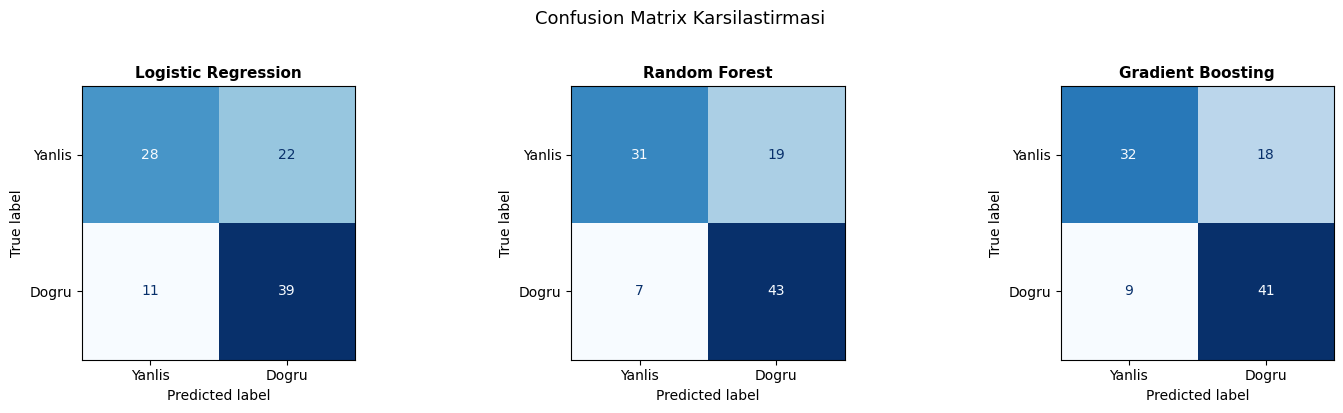

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, v) in zip(axes, ml_results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Yanlis', 'Dogru']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix Karsilastirmasi', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PATHS['figures']}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC Eğrisi

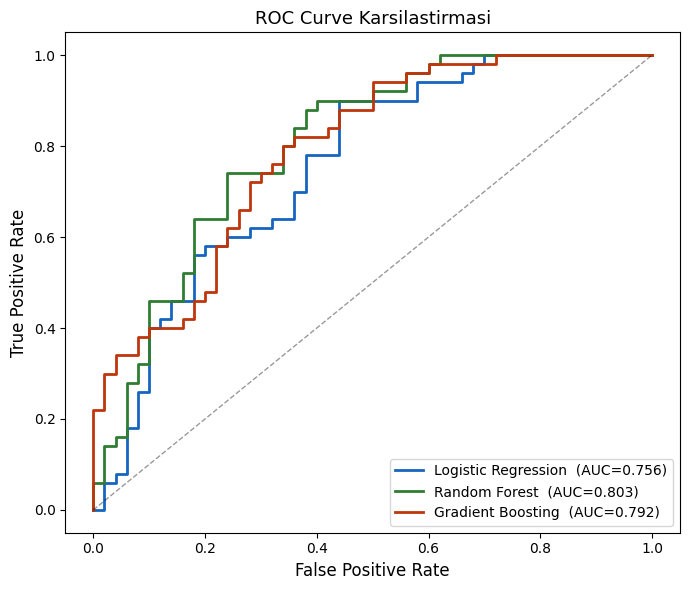

In [11]:
plt.figure(figsize=(7, 6))
colors = ['#1565C0', '#2E7D32', '#BF360C']

for (name, v), color in zip(ml_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{name}  (AUC={v['ROC-AUC']:.3f})")

plt.plot([0,1],[0,1], 'k--', alpha=0.4, lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Karsilastirmasi', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{PATHS['figures']}/roc_curves.png", dpi=150)
plt.show()

## 12. Feature Importance

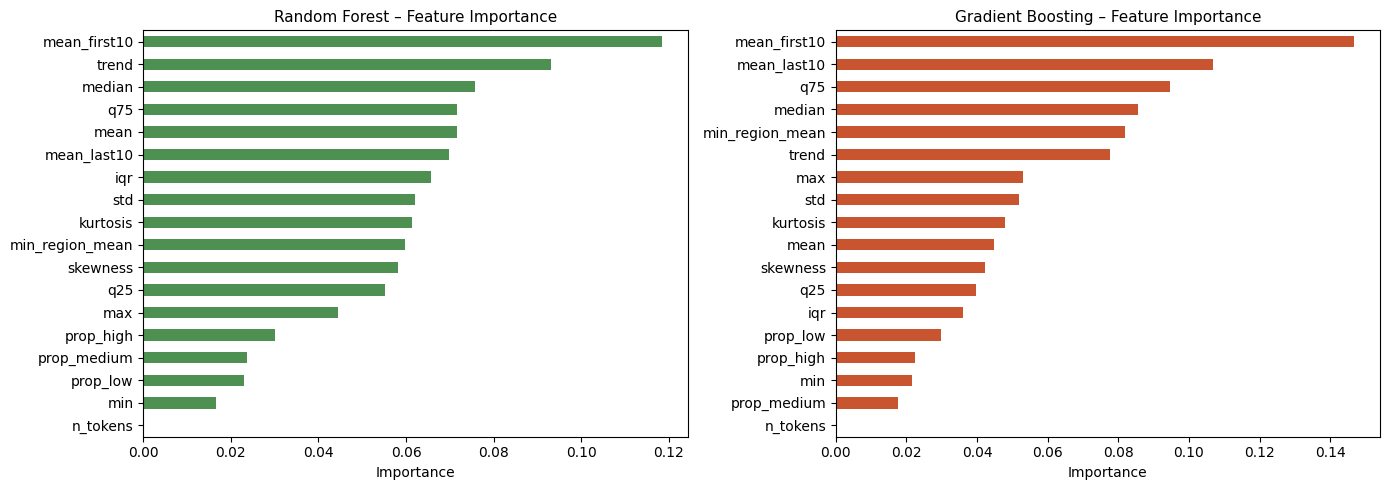


=== En Önemli 5 Özellik (Gradient Boosting) ===
mean_first10       0.146739
mean_last10        0.106784
q75                0.094698
median             0.085590
min_region_mean    0.081803


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name, color in zip(
        axes,
        ['Random Forest', 'Gradient Boosting'],
        ['#2E7D32', '#BF360C']):

    clf = ml_results[model_name]['clf'].named_steps['clf']  # pipeline içinden al
    imp = pd.Series(clf.feature_importances_, index=FEATURE_NAMES).sort_values()
    imp.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'{model_name} – Feature Importance', fontsize=11)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(f"{PATHS['figures']}/feature_importance.png", dpi=150)
plt.show()

print('\n=== En Önemli 5 Özellik (Gradient Boosting) ===')
gb_clf = ml_results['Gradient Boosting']['clf'].named_steps['clf']
gb_imp = pd.Series(gb_clf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(gb_imp.head(5).to_string())

## 13. Top1−Top2 Fark Dağılımının Görselleştirilmesi

/tmp/ipykernel_430/1567658480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='label', y='mean_diff',


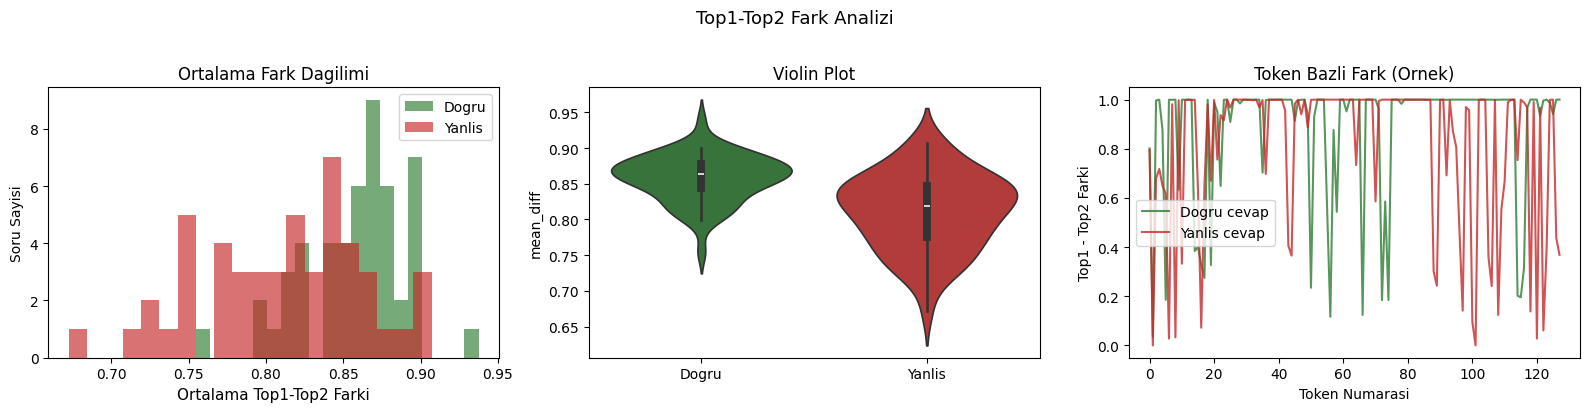

In [13]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Ortalama fark histogramı
c_means = [np.mean(r) for r in test_df[test_df['is_correct']==True]['top_diffs']]
w_means = [np.mean(r) for r in test_df[test_df['is_correct']==False]['top_diffs']]
axes[0].hist(c_means, bins=20, alpha=0.65, color='#2E7D32', label='Dogru')
axes[0].hist(w_means, bins=20, alpha=0.65, color='#C62828', label='Yanlis')
axes[0].set_xlabel('Ortalama Top1-Top2 Farki', fontsize=11)
axes[0].set_ylabel('Soru Sayisi')
axes[0].set_title('Ortalama Fark Dagilimi')
axes[0].legend()

# 2) Violin plot — sınıfa göre ortalama fark
plot_df = pd.DataFrame({
    'mean_diff' : c_means + w_means,
    'label'     : ['Dogru']*len(c_means) + ['Yanlis']*len(w_means)
})
sns.violinplot(data=plot_df, x='label', y='mean_diff',
               palette={'Dogru':'#2E7D32','Yanlis':'#C62828'}, ax=axes[1])
axes[1].set_title('Violin Plot')
axes[1].set_xlabel('')

# 3) Örnek token bazlı fark grafiği
sample_c = test_df[test_df['is_correct']==True].iloc[0]['top_diffs']
sample_w = test_df[test_df['is_correct']==False].iloc[0]['top_diffs']
axes[2].plot(sample_c, alpha=0.8, color='#2E7D32', label='Dogru cevap')
axes[2].plot(sample_w, alpha=0.8, color='#C62828', label='Yanlis cevap')
axes[2].set_xlabel('Token Numarasi')
axes[2].set_ylabel('Top1 - Top2 Farki')
axes[2].set_title('Token Bazli Fark (Ornek)')
axes[2].legend()

plt.suptitle('Top1-Top2 Fark Analizi', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PATHS['figures']}/top1_top2_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## 14. Sonuçların Drive'a Kaydedilmesi

In [18]:
# Tablo ve metrikler JSON olarak kaydet
MODEL_NAME = 'ytu-ce-cosmos/Turkish-Gemma-9b-T1'

summary = {
    'dataset'     : 'ytu-ce-cosmos/gsm8k_tr',
    'model'       : MODEL_NAME ,
    'n_train'     : len(train_df),
    'n_test'      : len(test_df),
    'features'    : FEATURE_NAMES,
    'results'     : {
        name: {
            k: round(v, 6) for k, v in vals.items()
            if k not in ('y_pred', 'y_prob', 'clf')
        }
        for name, vals in ml_results.items()
    },
    'best_model'  : best,
}

summary_path = f"{PATHS['results']}/summary.json"
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Kaydedildi:', summary_path)
print()
print('=== ÖZET ===')
print(tablo.to_string())
print(f'\nEn iyi model: {best}')

Kaydedildi: /content/drive/MyDrive/top1top2_proje/results/summary.json

=== ÖZET ===
                    Accuracy Precision  Recall F1-score ROC-AUC
Logistic Regression   0.6700    0.6393  0.7800   0.7027  0.7560
Random Forest         0.7400    0.6935  0.8600   0.7679  0.8032
Gradient Boosting     0.7300    0.6949  0.8200   0.7523  0.7916

En iyi model: Random Forest
